In [2]:
import pandas as pd
path_screen = r"C:\GoogleDrive\TP\screen\screen_aggregate.pkl"
path_screen = r"C:\GoogleDrive\TP\screen\screen_need_to_transform3.parquet"
path_returns = r"C:\GoogleDrive\TP\screen\returns.pkl"

In [3]:
# screen = pd.read_pickle(path_screen)
screen = pd.read_parquet(path_screen)

In [ ]:
def factset_icb_mapping(df, path_params = r"C:\GoogleDrive\TP\screen\factset_icb_mapping.xlsx"):

    df_mapping = pd.read_excel(path_params, sheet_name='Mapping', header = 0, na_values="@NA")
    df_mapping.rename(columns={'Benchmark ICB Supersector 19' : ' Benchmark ICB Supersector ', 'Benchmark ICB Industry 11' : ' Benchmark ICB Industry '}, inplace= True)

    df_FS_ICB = df_mapping[['FactSet Ind', 'Transco_ICB_19']]
    df_FS_ICB.rename(columns={'Transco_ICB_19' : 'ICB19'}, inplace= True)

    df_ICB_19_to_11 = df_mapping[['ICB_19_mapping', 'Transco_ICB_11']]
    df_ICB_19_to_11.rename(columns={'Transco_ICB_11' : 'ICB11'}, inplace= True)

    df_ICB_19_num = df_mapping.loc[df_mapping['ICB19_ID'].notna(),[' Benchmark ICB Supersector ','ICB19_ID']]
    df_ICB_11_num = df_mapping.loc[df_mapping['ICB11_ID'].notna(),[' Benchmark ICB Industry ','ICB11_ID']]

    df = df.reset_index().merge(df_ICB_19_num, how='left', on = ' Benchmark ICB Supersector ').set_index('ISIN')
    df[' Benchmark ICB Supersector '] = df['ICB19_ID']
    df = df.reset_index().merge(df_FS_ICB, how='left', on = 'FactSet Ind').set_index('ISIN')
    df.loc[df[' Benchmark ICB Supersector '] == 0, ' Benchmark ICB Supersector '] = df.loc[df[' Benchmark ICB Supersector '] == 0, 'ICB19'].values

    df = df.reset_index().merge(df_ICB_11_num, how='left', on = ' Benchmark ICB Industry ').set_index('ISIN')
    df[' Benchmark ICB Industry '] = df['ICB11_ID']
    df = df.reset_index().merge(df_ICB_19_to_11, how='left', left_on = ' Benchmark ICB Supersector ', right_on="ICB_19_mapping").set_index('ISIN')
    df.loc[df[' Benchmark ICB Industry '] == 0, ' Benchmark ICB Industry '] = df.loc[df[' Benchmark ICB Industry '] == 0, 'ICB11'].values

    df.drop(columns = ['ICB19','ICB19_ID','ICB11','ICB11_ID','ICB_19_mapping'],inplace=True)

    df['Date'] = pd.to_datetime(df['Date'])

    return df

In [4]:
def factset_icb_mapping(df, path_params = r"C:\GoogleDrive\TP\screen\factset_icb_mapping.xlsx"):
    
    # 读取映射文件
    df_mapping = pd.read_excel(path_params, sheet_name='Mapping', header=0, na_values="@NA")
    df_mapping.rename(columns={
        'Benchmark ICB Supersector 19': ' Benchmark ICB Supersector ',
        'Benchmark ICB Industry 11': ' Benchmark ICB Industry '
    }, inplace=True)
    
    # 创建映射字典 - 添加去重处理
    # 1. Supersector -> ICB19_ID
    mapping_sector_to_id = (df_mapping.dropna(subset=['ICB19_ID'])
                            .drop_duplicates(subset=[' Benchmark ICB Supersector '])
                            .set_index(' Benchmark ICB Supersector ')['ICB19_ID']
                            .to_dict())
    
    # 2. FactSet Ind -> ICB19
    mapping_factset_to_icb19 = (df_mapping
                                .drop_duplicates(subset=['FactSet Ind'])
                                .set_index('FactSet Ind')['Transco_ICB_19']
                                .to_dict())
    
    # 3. Industry -> ICB11_ID
    mapping_industry_to_id = (df_mapping.dropna(subset=['ICB11_ID'])
                              .drop_duplicates(subset=[' Benchmark ICB Industry '])
                              .set_index(' Benchmark ICB Industry ')['ICB11_ID']
                              .to_dict())
    
    # 4. ICB19 -> ICB11 (这里最可能出现重复)
    mapping_icb19_to_icb11 = (df_mapping
                              .drop_duplicates(subset=['ICB_19_mapping'])
                              .set_index('ICB_19_mapping')['Transco_ICB_11']
                              .to_dict())
    
    # 重置索引一次
    df = df.reset_index()
    
    # 处理 Supersector 列
    df[' Benchmark ICB Supersector '] = df[' Benchmark ICB Supersector '].map(mapping_sector_to_id)
    
    # 当Supersector为0或NaN时，用FactSet Ind映射的值替换
    temp_icb19 = df['FactSet Ind'].map(mapping_factset_to_icb19)
    mask_sector_zero = (df[' Benchmark ICB Supersector '] == 0) | (df[' Benchmark ICB Supersector '].isna())
    df.loc[mask_sector_zero, ' Benchmark ICB Supersector '] = temp_icb19[mask_sector_zero]
    
    # 处理 Industry 列
    df[' Benchmark ICB Industry '] = df[' Benchmark ICB Industry '].map(mapping_industry_to_id)
    
    # 当Industry为0或NaN时，用Supersector映射到ICB11的值替换
    temp_icb11 = df[' Benchmark ICB Supersector '].map(mapping_icb19_to_icb11)
    mask_industry_zero = (df[' Benchmark ICB Industry '] == 0) | (df[' Benchmark ICB Industry '].isna())
    df.loc[mask_industry_zero, ' Benchmark ICB Industry '] = temp_icb11[mask_industry_zero]
    
    # 设置索引
    df.set_index('ISIN', inplace=True)
    
    # 日期转换
    df['Date'] = pd.to_datetime(df['Date'])
    
    return df

screen = factset_icb_mapping(screen)

if 'index' in screen.columns:
    screen.drop(columns="index", inplace=True)

In [24]:
screen['Date'] = screen['Date'] + pd.offsets.MonthEnd(-1)

In [37]:
screen.to_pickle(r"C:\GoogleDrive\TP\screen\screen_aggregate.pkl")

In [ ]:
screen['Benchmark Market Value Millions in EUR'].update(screen['Benchmark Market Value Millions in EUR'])
screen['Benchmark Market Value Millions in EUR'] = screen['Benchmark Market Value Millions in EUR']
screen.drop(columns="Benchmark Market Value Millions in EUR ", inplace=True)

In [32]:
import pandas as pd

# 假设你的列表叫 date_list
# data_list = [Timestamp('1999-12-31'), ... ] 

# 1. 转换成 Series
s = pd.Series(screen['Date'].unique())

# 2. 生成一个完美的“预期”时间范围 (频率 'M' 代表月末)
# 注意：Pandas 会自动处理大小月和闰年
expected_range = pd.date_range(start=s.min(), end=s.max(), freq='M')  
# (注：如果你的 pandas 是新版，可能需要用 freq='ME')

# 3. 比对长度
print(f"实际长度: {len(s)}")
print(f"预期长度: {len(expected_range)}")

# 4. 找出缺失的日期 (集合运算)
missing = set(expected_range) - set(s)

if not missing:
    print("✅ 完美！没有缺失任何月份。")
else:
    print(f"❌ 发现缺失: {missing}")

实际长度: 312
预期长度: 312
✅ 完美！没有缺失任何月份。


In [40]:
screen_ml = screen[screen['Date'] > pd.Timestamp('2005-01-01')]
screen_ml.to_pickle(r"C:\GoogleDrive\TP\ML_Enhanced\Input_files\screen_aggregate.parquet")

MemoryError: Unable to allocate 1.49 GiB for an array with shape (74, 2706296) and data type float64

In [39]:
path_screen = r"C:\GoogleDrive\TP\screen\screen_aggregate.pkl"
path_returns = r"C:\GoogleDrive\TP\screen\returns.pkl"
path_score = r"C:\GoogleDrive\TP\ML\Output_files\SCORE_ML_US.pkl"

screen_agg = pd.read_pickle(path_screen)  
screen_agg.reset_index(inplace=True)  # index will become 0 1 2 3 4 5 6...

# Prepare prediction results with matching index  
output_last_month = pd.read_pickle(path_score) 
output_last_month.reset_index(inplace=True)  

# Step 1: Prepare historical and prediction data for merging
# We sort both datasets by 'Date' and 'ISIN' to ensure proper alignment for merge_asof
score_histo = screen_agg.sort_values(['Date', 'ISIN'])[['ISIN', 'Date']]
score_prod = output_last_month.sort_values(['Date', 'ISIN'])[['ISIN', 'Date', 'Score ML']]

# 📊 Example:
# score_histo:
# ┌───────┬────────────┐
# │ ISIN  │    Date     │
# ├───────┼────────────┤
# │ FR001 │ 2025-08-29  │
# │ FR002 │ 2025-08-29  │
# └───────┴────────────┘

# score_prod:
# ┌───────┬────────────┬────────┐
# │ ISIN  │    Date     │ Score ML │
# ├───────┼────────────┼────────┤
# │ FR001 │ 2025-08-31  │  0.87  │
# │ FR002 │ 2025-08-31  │  0.65  │
# └───────┴────────────┴────────┘

# Step 2: Perform merge_asof to align scores by nearest date (within 7 days)
# This allows us to match prediction scores to historical entries even if dates differ slightly
merged = pd.merge_asof(
    score_histo[['ISIN', 'Date']],
    score_prod,
    on='Date', by='ISIN',
    direction='nearest',
    tolerance=pd.Timedelta('7D')
)

merged = merged.dropna(subset='Score ML')

# 📊 merged:
# ┌───────┬────────────┬────────┐
# │ ISIN  │    Date     │ Score ML │
# ├───────┼────────────┼────────┤
# │ FR001 │ 2025-08-29  │  0.87  │ ← matched within 2 days
# │ FR002 │ 2025-08-29  │  0.65  │ ← matched within 2 days
# └───────┴────────────┴────────┘


# Step 3: Update 'Score ML' in screen_agg only where 'Score ML' in merged is available
# Update methode:
# Replaces existing values with values from another DataFrame where the index and columns match.
# Does not preserve original values — it overwrites them.
# Requires aligned index and columns.
screen_agg.set_index(['ISIN', 'Date'], inplace=True)
merged.set_index(['ISIN', 'Date'], inplace=True)

screen_agg['Score ML'].update(merged['Score ML'])

# Show how many rows are updated
updated_rows = merged.shape[0]
print(f"Updated 'Score ML' for {updated_rows} rows.")


# Reset index for scrren_agg
screen_agg.reset_index(inplace=True)
screen_agg.set_index('ISIN', inplace=True)

# ✅ Final screen_agg:
# ┌───────┬────────────┬───────────┐
# │ ISIN  │    Date     │ Score ML  │
# ├───────┼────────────┼───────────┤
# │ FR001 │ 2025-08-29  │   0.87    │
# │ FR002 │ 2025-08-29  │   0.65    │
# └───────┴────────────┴───────────┘

# Save updated file  
screen_agg.to_pickle(path_screen)  
print(f"Screen aggregate file updated successfully at: {path_screen}")  

Updated 'Score ML' for 16942 rows.
Screen aggregate file updated successfully at: C:\GoogleDrive\TP\screen\screen_aggregate.pkl


In [40]:
EU = pd.read_pickle(r"C:\GoogleDrive\TP\ML\Input_files\screen_ML_EU.pkl")

In [41]:
EU

index          ISIN    Symbol  \
Company SEDOL Date                                        
S0YJ3Z-R      2017-07-31      0  AT0000606306  S0YJ3Z-R   
              2017-08-31      1  AT0000606306  S0YJ3Z-R   
              2017-09-30      2  AT0000606306  S0YJ3Z-R   
              2017-10-31      3  AT0000606306  S0YJ3Z-R   
              2017-11-30      4  AT0000606306  S0YJ3Z-R   
...                         ...           ...       ...   
L5JGFL-R      2020-04-30  57573  ZAE000255360  L5JGFL-R   
              2020-05-31  57574  ZAE000255360  L5JGFL-R   
              2020-06-30  57575  ZAE000255360  L5JGFL-R   
              2020-07-31  57576  ZAE000255360  L5JGFL-R   
              2020-08-31  57577  ZAE000255360  L5JGFL-R   

                                                      Name  \
Company SEDOL Date                                           
S0YJ3Z-R      2017-07-31  Raiffeisen Bank International AG   
              2017-08-31  Raiffeisen Bank International AG   
              2017-09-30  Raiffeisen Bank International AG   
              2017-10-31  Raiffeisen Bank International AG   
              2017-11-30  Raiffeisen Bank International AG   
...                                                    ...   
L5JGFL-R      2020-04-30                   Old Mutual Ltd.   
              2020-05-31                   Old Mutual Ltd.   
              2020-06-30                   Old Mutual Ltd.   
              2020-07-31                   Old Mutual Ltd.   
              2020-08-31                   Old Mutual Ltd.   

                         Exchange Country Name            FactSet Ind  \
Company SEDOL Date                                                      
S0YJ3Z-R      2017-07-31               AUSTRIA            Major Banks   
              2017-08-31               AUSTRIA            Major Banks   
              2017-09-30               AUSTRIA            Major Banks   
              2017-10-31               AUSTRIA            Major Banks   
              2017-11-30               AUSTRIA            Major Banks   
...                                        ...                    ...   
L5JGFL-R      2020-04-30          SOUTH AFRICA  Life/Health Insurance   
              2020-05-31          SOUTH AFRICA  Life/Health Insurance   
              2020-06-30          SOUTH AFRICA  Life/Health Insurance   
              2020-07-31          SOUTH AFRICA  Life/Health Insurance   
              2020-08-31          SOUTH AFRICA  Life/Health Insurance   

                         FactSet Economy Curncy Iso       Region  \
Company SEDOL Date                                                 
S0YJ3Z-R      2017-07-31         FINANCE        EUR  West Europe   
              2017-08-31         FINANCE        EUR  West Europe   
              2017-09-30         FINANCE        EUR  West Europe   
              2017-10-31         FINANCE        EUR  West Europe   
              2017-11-30         FINANCE        EUR  West Europe   
...                                  ...        ...          ...   
L5JGFL-R      2020-04-30         FINANCE        ZAR       Africa   
              2020-05-31         FINANCE        ZAR       Africa   
              2020-06-30         FINANCE        ZAR       Africa   
              2020-07-31         FINANCE        ZAR       Africa   
              2020-08-31         FINANCE        ZAR       Africa   

                          Sector ICB11  ...  Sector 12  Sector 13  Sector 14  \
Company SEDOL Date                      ...                                    
S0YJ3Z-R      2017-07-31           5.0  ...      False      False      False   
              2017-08-31           5.0  ...      False      False      False   
              2017-09-30           5.0  ...      False      False      False   
              2017-10-31           5.0  ...      False      False      False   
              2017-11-30           5.0  ...      False      False      False   
...                                ...  ...        ...  

In [43]:
returns = pd.read_pickle(path_returns)

<Axes: >

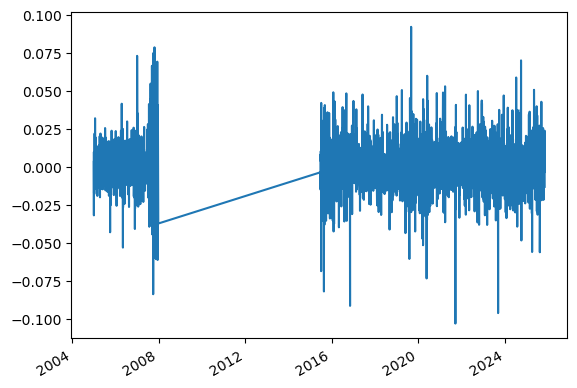

: 

In [ ]:
returns.iloc[:, 0].plot()

In [6]:
screen.groupby("Date")['Score ML'].mean()

Date
2017-07-31         NaN
2017-08-31         NaN
2017-09-30         NaN
2017-10-31         NaN
2017-11-30         NaN
                ...   
2025-06-30    5.009066
2025-07-31    5.009074
2025-08-31    5.009083
2025-09-30    5.009083
2025-10-31    5.009083
Name: Score ML, Length: 100, dtype: float64

In [8]:
screen['Date'].min()

Timestamp('2017-07-31 00:00:00')

Concat Monthly - Excel to Pickle

In [1]:
def factset_icb_mapping(df, path_params = r"C:\GoogleDrive\TP\screen\factset_icb_mapping.xlsx"):
    
    # 读取映射文件
    df_mapping = pd.read_excel(path_params, sheet_name='Mapping', header=0, na_values="@NA")
    df_mapping.rename(columns={
        'Benchmark ICB Supersector 19': ' Benchmark ICB Supersector ',
        'Benchmark ICB Industry 11': ' Benchmark ICB Industry '
    }, inplace=True)
    
    # 创建映射字典 - 添加去重处理
    # 1. Supersector -> ICB19_ID
    mapping_sector_to_id = (df_mapping.dropna(subset=['ICB19_ID'])
                            .drop_duplicates(subset=[' Benchmark ICB Supersector '])
                            .set_index(' Benchmark ICB Supersector ')['ICB19_ID']
                            .to_dict())
    
    # 2. FactSet Ind -> ICB19
    mapping_factset_to_icb19 = (df_mapping
                                .drop_duplicates(subset=['FactSet Ind'])
                                .set_index('FactSet Ind')['Transco_ICB_19']
                                .to_dict())
    
    # 3. Industry -> ICB11_ID
    mapping_industry_to_id = (df_mapping.dropna(subset=['ICB11_ID'])
                              .drop_duplicates(subset=[' Benchmark ICB Industry '])
                              .set_index(' Benchmark ICB Industry ')['ICB11_ID']
                              .to_dict())
    
    # 4. ICB19 -> ICB11 (这里最可能出现重复)
    mapping_icb19_to_icb11 = (df_mapping
                              .drop_duplicates(subset=['ICB_19_mapping'])
                              .set_index('ICB_19_mapping')['Transco_ICB_11']
                              .to_dict())
    
    # 重置索引一次
    df = df.reset_index()
    
    # 处理 Supersector 列
    df[' Benchmark ICB Supersector '] = df[' Benchmark ICB Supersector '].map(mapping_sector_to_id)
    
    # 当Supersector为0或NaN时，用FactSet Ind映射的值替换
    temp_icb19 = df['FactSet Ind'].map(mapping_factset_to_icb19)
    mask_sector_zero = (df[' Benchmark ICB Supersector '] == 0) | (df[' Benchmark ICB Supersector '].isna())
    df.loc[mask_sector_zero, ' Benchmark ICB Supersector '] = temp_icb19[mask_sector_zero]
    
    # 处理 Industry 列
    df[' Benchmark ICB Industry '] = df[' Benchmark ICB Industry '].map(mapping_industry_to_id)
    
    # 当Industry为0或NaN时，用Supersector映射到ICB11的值替换
    temp_icb11 = df[' Benchmark ICB Supersector '].map(mapping_icb19_to_icb11)
    mask_industry_zero = (df[' Benchmark ICB Industry '] == 0) | (df[' Benchmark ICB Industry '].isna())
    df.loc[mask_industry_zero, ' Benchmark ICB Industry '] = temp_icb11[mask_industry_zero]
    
    # 设置索引
    df.set_index('ISIN', inplace=True)
    
    # 日期转换
    df['Date'] = pd.to_datetime(df['Date'])
    
    return df



In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# 指定目录路径
directory = Path(r"C:\GoogleDrive\TP\screen\monthly")

# 获取所有Excel文件
excel_files = list(directory.glob("*.xlsx")) + list(directory.glob("*.xls"))

print(f"找到 {len(excel_files)} 个Excel文件\n")

# 读取所有Excel文件并显示进度条
dfs = []
for file in tqdm(excel_files, desc="读取进度", unit="文件"):
    df_temp = pd.read_excel(file, skiprows=4)
    dfs.append(df_temp)
    # 可选：显示每个文件的行数
    tqdm.write(f"✓ {file.name}: {len(df_temp)} 行")

# 拼接所有dataframe
print("\n正在拼接数据...")
df = pd.concat(dfs, axis=0)

print(f"\n✓ 拼接完成！")
print(f"总共读取了 {len(excel_files)} 个文件")
print(f"最终DataFrame形状: {df.shape}")
print(f"\n前几行数据：")
print(df.head())

# 调整日期到每月月底
print("\n正在调整日期到每月月底...")
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df['Date'] = df['Date'] + pd.offsets.MonthBegin(1)              # 先转换为第二个月的第一天
df['Date'] = df['Date'] + pd.offsets.MonthEnd(-1)               # 再转换回上个月的月底

# 处理Benchmark Market Value Millions in EUR列（如果存在）
if 'Benchmark Market Value Millions in EUR ' in df.columns:
    print("\n正在处理 'Benchmark Market Value Millions in EUR ' 列...")
    df['Benchmark Market Value Millions in EUR '].update(df['Benchmark Market Value Millions in EUR'])
    df['Benchmark Market Value Millions in EUR'] = df['Benchmark Market Value Millions in EUR ']
    df.drop(columns="Benchmark Market Value Millions in EUR ", inplace=True)

# 应用FactSet ICB映射
print("\n正在应用 FactSet ICB 映射...")
df = factset_icb_mapping(df)

# 删除多余的index列（如果存在）
if 'index' in df.columns:
    df.drop(columns="index", inplace=True)

# 检查重复项
print("\n正在检查重复项...")
print(f"原始数据形状: {df.shape}")
if 'ISIN' not in df.columns and df.index.name == "ISIN":
    df.reset_index(inplace=True)
duplicates = df.duplicated(subset=['ISIN', 'Date'], keep=False)
print(f"发现 {duplicates.sum()} 行重复数据")
print(f"涉及 {df[duplicates].groupby(['ISIN', 'Date']).ngroups} 个重复组")

# 合并重复项
print("\n正在合并重复项...")
df = (
    df
    .groupby(['ISIN', 'Date'], group_keys=False)
    .apply(lambda g: g.bfill().ffill().iloc[0] if len(g) > 1 else g.iloc[0])
    .reset_index(drop=True)
)

print(f"\n✓ 合并完成！")
print(f"去重后形状: {df.shape}")
print(f"删除了 {df.shape[0] - df.shape[0]} 行重复数据")

# 清理"@NA"值
df = df.replace('@NA', np.nan)
df.dropna(subset="ISIN", inplace=True)

In [ ]:
# df = screen_new.copy(deep=True)

Add Bench

In [56]:
import pandas as pd
import os

def load_and_merge_benchmark(bench_dir, benchmark_name):
    """
    加载benchmark数据并合并ticker mapping信息
    
    Parameters:
    -----------
    bench_dir : str
        benchmark文件所在目录路径
    benchmark_name : str
        benchmark基础名称（不含扩展名），如 'stoxx_europe_600', 'sp500', 'nasdaq'
    
    Returns:
    --------
    pd.DataFrame
        合并后的完整数据框
    """
    # 构建文件路径
    pickle_path = os.path.join(bench_dir, f"{benchmark_name}.pickle")
    excel_path = os.path.join(bench_dir, f"{benchmark_name}_tickers_names.xlsx")
    
    # 检查文件是否存在
    if not os.path.exists(pickle_path):
        raise FileNotFoundError(f"找不到文件: {pickle_path}")
    if not os.path.exists(excel_path):
        raise FileNotFoundError(f"找不到文件: {excel_path}")
    
    print(f"\n{'='*60}")
    print(f"正在加载 {benchmark_name}...")
    print(f"{'='*60}")
    
    # 加载数据
    df_main = pd.read_pickle(pickle_path)
    df_mapping = pd.read_excel(excel_path)
    
    print(f"主数据形状: {df_main.shape}")
    print(f"映射数据形状: {df_mapping.shape}")
    
    # 清理和标准化Ticker列
    if 'Ticker' in df_main.columns:
        df_main['Ticker'] = df_main['Ticker'].astype(str).str.strip()
    if 'Ticker' in df_mapping.columns:
        df_mapping['Ticker'] = df_mapping['Ticker'].astype(str).str.strip()
    
    # 显示数据类型
    print(f"主数据 Ticker 类型: {df_main['Ticker'].dtype}")
    print(f"映射数据 Ticker 类型: {df_mapping['Ticker'].dtype}")
    
    # 合并数据
    df_merged = pd.merge(
        df_main,
        df_mapping[['Ticker', 'ISIN', 'Long Name']],
        on='Ticker',
        how='left'
    )
    
    # 确保Date列是datetime类型
    df_merged['Rebalance Period'] = pd.to_datetime(df_merged['Rebalance Period'])
    df_merged['Rebalance Period'] = df_merged['Rebalance Period'] + pd.offsets.MonthBegin(1)              # 先转换为第二个月的第一天
    df_merged['Rebalance Period'] = df_merged['Rebalance Period'] + pd.offsets.MonthEnd(-1)               # 再转换回上个月的月底

    # 检查合并结果
    print(f"合并后形状: {df_merged.shape}")
    unmatched = df_merged['ISIN'].isna().sum()
    print(f"未匹配的记录数: {unmatched}")
    
    if unmatched > 0:
        print(f"⚠️ 警告: 有 {unmatched} 条记录未找到对应的ISIN和Long Name")
        print("未匹配的Ticker示例:")
        print(df_merged[df_merged['ISIN'].isna()]['Ticker'].unique()[:10])
    
    print(f"✓ {benchmark_name} 加载完成!\n")
    
    return df_merged

In [ ]:
# 设置benchmark目录
bench_dir = r"C:\GoogleDrive\TP\screen\bench"

# 方法1: 手动加载和更新
stoxx600 = load_and_merge_benchmark(bench_dir, 'stoxx_europe_600')
sp500 = load_and_merge_benchmark(bench_dir, 'sp500')
nasdaq = load_and_merge_benchmark(bench_dir, 'nasdaq')

# df = screen_new.copy(deep=True)

# 更新权重列
df[["Weight in SP500", "Weight in STOXX EUROPE 600", "Weight in NASDAQ COMP"]] = np.nan
df.set_index(['ISIN', 'Date'], inplace=True)
nasdaq.set_index(['ISIN', 'Rebalance Period'], inplace=True)
df['Weight in NASDAQ COMP'].update(nasdaq['Weight'])
stoxx600.set_index(['ISIN', 'Rebalance Period'], inplace=True)
stoxx600.drop_duplicates(inplace=True)
df['Weight in STOXX EUROPE 600'].update(stoxx600['Weight'])
sp500.set_index(['ISIN', 'Rebalance Period'], inplace=True)
df['Weight in SP500'].update(sp500['Weight'])

df.reset_index(inplace=True)
df = df.set_index('ISIN')


正在加载 stoxx_europe_600...
主数据形状: (26263, 6)
映射数据形状: (734, 4)
主数据 Ticker 类型: object
映射数据 Ticker 类型: object
合并后形状: (26263, 8)
未匹配的记录数: 0
✓ stoxx_europe_600 加载完成!


正在加载 sp500...
主数据形状: (21507, 6)
映射数据形状: (591, 4)
主数据 Ticker 类型: object
映射数据 Ticker 类型: object
合并后形状: (21507, 8)
未匹配的记录数: 42
⚠️ 警告: 有 42 条记录未找到对应的ISIN和Long Name
未匹配的Ticker示例:
['1518855D US']
✓ sp500 加载完成!


正在加载 nasdaq...
主数据形状: (4489, 6)
映射数据形状: (139, 4)
主数据 Ticker 类型: object
映射数据 Ticker 类型: object
合并后形状: (4489, 8)
未匹配的记录数: 42
⚠️ 警告: 有 42 条记录未找到对应的ISIN和Long Name
未匹配的Ticker示例:
['1518855D US']
✓ nasdaq 加载完成!



In [85]:
screen_agg = pd.read_pickle(r"C:\GoogleDrive\TP\screen\screen_aggregate.pkl")
screen_agg = pd.concat([screen_agg, df], axis=0)
screen_agg = screen_agg.sort_values(by="Date")
screen_agg.to_pickle(r"C:\GoogleDrive\TP\screen\screen_aggregate.pkl")

更新ML分数

In [4]:
def update_screen_with_ML(path_screen, path_score):
    screen_agg = pd.read_pickle(path_screen)
    screen_agg.reset_index(inplace=True)  # index will become 0 1 2 3 4 5 6...
    
    # Prepare prediction results with matching index  
    output_last_month = pd.read_pickle(path_score)  
    output_last_month.reset_index(inplace=True)  

    # Step 1: Prepare historical and prediction data for merging
    # We sort both datasets by 'Date' and 'ISIN' to ensure proper alignment for merge_asof
    score_histo = screen_agg.sort_values(['Date', 'ISIN'])[['ISIN', 'Date']]
    score_prod = output_last_month.sort_values(['Date', 'ISIN'])[['ISIN', 'Date', 'Score ML']]

    # 📊 Example:
    # score_histo:
    # ┌───────┬────────────┐
    # │ ISIN  │    Date     │
    # ├───────┼────────────┤
    # │ FR001 │ 2025-08-29  │
    # │ FR002 │ 2025-08-29  │
    # └───────┴────────────┘

    # score_prod:
    # ┌───────┬────────────┬────────┐
    # │ ISIN  │    Date     │ Score ML │
    # ├───────┼────────────┼────────┤
    # │ FR001 │ 2025-08-31  │  0.87  │
    # │ FR002 │ 2025-08-31  │  0.65  │
    # └───────┴────────────┴────────┘

    # Step 2: Perform merge_asof to align scores by nearest date (within 7 days)
    # This allows us to match prediction scores to historical entries even if dates differ slightly
    merged = pd.merge_asof(
        score_histo[['ISIN', 'Date']],
        score_prod,
        on='Date', by='ISIN',
        direction='nearest',
        tolerance=pd.Timedelta('7D')
    )

    merged = merged.dropna(subset='Score ML')

    # 📊 merged:
    # ┌───────┬────────────┬────────┐
    # │ ISIN  │    Date     │ Score ML │
    # ├───────┼────────────┼────────┤
    # │ FR001 │ 2025-08-29  │  0.87  │ ← matched within 2 days
    # │ FR002 │ 2025-08-29  │  0.65  │ ← matched within 2 days
    # └───────┴────────────┴────────┘


    # Step 3: Update 'Score ML' in screen_agg only where 'Score ML' in merged is available
    # Update methode:
    # Replaces existing values with values from another DataFrame where the index and columns match.
    # Does not preserve original values — it overwrites them.
    # Requires aligned index and columns.
    screen_agg.set_index(['ISIN', 'Date'], inplace=True)
    merged.set_index(['ISIN', 'Date'], inplace=True)

    screen_agg['Score ML'].update(merged['Score ML'])
    
    # Show how many rows are updated
    updated_rows = merged.shape[0]
    print(f"Updated 'Score ML' for {updated_rows} rows.")


    # Reset index for scrren_agg
    screen_agg.reset_index(inplace=True)
    screen_agg.set_index('ISIN', inplace=True)

    # ✅ Final screen_agg:
    # ┌───────┬────────────┬───────────┐
    # │ ISIN  │    Date     │ Score ML  │
    # ├───────┼────────────┼───────────┤
    # │ FR001 │ 2025-08-29  │   0.87    │
    # │ FR002 │ 2025-08-29  │   0.65    │
    # └───────┴────────────┴───────────┘

    # Save updated file  
    screen_agg.to_pickle(path_screen)  
    print(f"Screen aggregate file updated successfully at: {path_screen}")  

In [5]:
import pandas as pd
path_screen = r"C:\GoogleDrive\TP\screen\screen_aggregate.pkl"
path_eu = r"C:\GoogleDrive\TP\ML\Output_files\SCORE_ML_EU.pkl"
path_us = r"C:\GoogleDrive\TP\ML\Output_files\SCORE_ML_US.pkl"

update_screen_with_ML(path_screen, path_eu)
update_screen_with_ML(path_screen, path_us)

Updated 'Score ML' for 44612 rows.
Screen aggregate file updated successfully at: C:\GoogleDrive\TP\screen\screen_aggregate.pkl
Updated 'Score ML' for 38145 rows.
Screen aggregate file updated successfully at: C:\GoogleDrive\TP\screen\screen_aggregate.pkl


test

In [39]:
df = pd.read_pickle(r"C:\GoogleDrive\TP\ML\Input_files\screen_ML_US - 副本.pkl")

In [41]:
df[df['ISIN'] == "US0378331005"][[   'Dividend Avg Percentile',
                                'Value Avg Percentile',
                                'Quality Avg Percentile',
                                'Mom Avg Percentile',
                                'LowVol Avg Percentile',
                                'Growth Avg Percentile',
                                'Value Avg Percentile_change_1M',
                                'Quality Avg Percentile_change_1M',
                                'Growth Avg Percentile_change_1M',
                                'Value Avg Percentile_change_3M',
                                'Quality Avg Percentile_change_3M',
                                'Growth Avg Percentile_change_3M',
                                'Value Avg Percentile_change_6M',
                                'Quality Avg Percentile_change_6M',
                                'Growth Avg Percentile_change_6M',
                                'Value Avg Percentile_change_12M',
                                'Quality Avg Percentile_change_12M',
                                'Growth Avg Percentile_change_12M',
                                'Sector 1',
                                'Sector 2',
                                'Sector 3',
                                'Sector 4',
                                'Sector 5',
                                'Sector 6',
                                'Sector 7',
                                'Sector 8',
                                'Sector 9',
                                'Sector 10',
                                'Sector 11',
                                'Sector 12',
                                'Sector 13',
                                'Sector 14',
                                'Sector 15',
                                'Sector 16',
                                'Sector 17',
                                'Sector 18',
                                'Sector 19'
                            ]]

Dividend Avg Percentile  Value Avg Percentile  \
Company SEDOL Date                                                        
MH33D6-R      2013-12-31                     4.52              2.738500   
              2014-01-31                     4.52              2.756833   
              2014-02-28                     4.52              2.756833   
              2014-03-31                     4.70              2.765833   
              2014-04-30                     4.80              2.738167   
...                                           ...                   ...   
              2025-06-30                     5.88              3.622667   
              2025-07-31                     5.86              3.632000   
              2025-08-31                     5.86              3.531167   
              2025-09-30                     5.72              3.631000   
              2025-10-31                     5.70              3.426667   

                          Quality Avg Percentile  Mom Avg Percentile  \
Company SEDOL Date                                                     
MH33D6-R      2013-12-31                   7.650                 3.7   
              2014-01-31                   7.650                 3.4   
              2014-02-28                   7.650                 2.7   
              2014-03-31                   7.700                 3.4   
              2014-04-30                   7.625                 6.5   
...                                          ...                 ...   
              2025-06-30                   7.500                 2.2   
              2025-07-31                   7.500                 1.6   
              2025-08-31                   7.500                 2.9   
              2025-09-30                   7.475                 3.6   
              2025-10-31                   7.500                 6.0   

                          LowVol Avg Percentile  Growth Avg Percentile  \
Company SEDOL Date                                                       
MH33D6-R      2013-12-31               5.000000               6.713333   
              2014-01-31               3.800000               6.743333   
              2014-02-28               4.066667               6.743333   
              2014-03-31               4.666667               6.710000   
              2014-04-30               4.066667               6.655000   
...                                         ...                    ...   
              2025-06-30               6.966667               5.583333   
              2025-07-31               7.166667               5.553333   
              2025-08-31               6.133333               5.553333   
              2025-09-30               5.900000               5.258333   
              2025-10-31               5.900000               5.640000   

                          Value Avg Percentile_change_1M  \
Company SEDOL Date                                         
MH33D6-R      2013-12-31                        0.000000   
              2014-01-31                        0.018333   
              2014-02-28                        0.000000   
              2014-03-31                        0.009000   
              2014-04-30                       -0.027666   
...                                                  ...   
              2025-06-30                        0.018334   
              2025-07-31                        0.009333   
              2025-08-31                       -0.100833   
              2025-09-30                        0.099833   
              2025-10-31                       -0.204333   

                          Quality Avg Percentile_change_1M  \
Company SEDOL Date                                           
MH33D6-R      2013-12-31                             0.000   
              2014-01-31                             0.000   
              2014-02-28                             0.000   
              2014-03-31                             0.050 

In [44]:
screen = pd.read_pickle(r"C:\GoogleDrive\TP\screen\screen_aggregate.pkl")

In [55]:
screen = screen[screen['Exchange Country Region'].isin(['North America','West Europe'])]
screen

,Date,Symbol,Name,Exchange Country Name,Company SEDOL,FactSet Ind,FactSet Economy,Curncy Iso,Exchange Country Region,Benchmark ICB Industry,...,PEG,Sales_5Y_growth,Total Employees CIQ,Non interest expense CIQ,Risk adj Assets CIQ,Gross Loans CIQ,Depreciation and Amort CIQ,Non perf Loans to Total Loans CIQ,Total Deposit CIQ,Score ML
ISIN,,,,,,,,,,,,,,,,,,,,,
US66765N1054,2013-12-31,NWN,Northwest Natural Holding Co.,UNITED STATES,TLPRD7-R,Gas Distributors,UTILITIES,USD,North America,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ES0105026001,2013-12-31,QLSLXX-R,Axiare Patrimonio SOCIMI SA,SPAIN,QLSLXX-R,Real Estate Investment Trusts,FINANCE,EUR,West Europe,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ES0105025003,2013-12-31,KK2X62-R,"MERLIN Properties SOCIMI, S.A.",SPAIN,KK2X62-R,Real Estate Investment Trusts,FINANCE,EUR,West Europe,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8334451098,2013-12-31,SNOW,"Snowflake, Inc.",UNITED STATES,JWW8TR-R,Packaged Software,TECHNOLOGY,USD,North America,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ES0105022000,2013-12-31,Q9HY8Y-R,APPLUS SERVICES S.A.,SPAIN,Q9HY8Y-R,Miscellaneous Commercial Services,INDUSTRIALS,EUR,West Europe,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FR0000062671,2025-10-31,R189Z9-R,Exail Technologies SA,FRANCE,R189Z9-R,Aerospace & Defense,TECHNOLOGY,EUR,West Europe,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US27616P3010,2025-10-31,DEA,Easterly Government Properties Inc,UNITED STATES,LXDS77-R,Real Estate Investment Trusts,FINANCE,USD,North America,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US03763A2078,2025-10-31,ASTH,Astrana Health Inc.,UNITED STATES,B15GK7-R,Services to the Health Industry,HEALTHCARE,USD,North America,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
screen[['Dividend Avg Percentile',
        'Value Avg Percentile',
        'Quality Avg Percentile',
        'Mom Avg Percentile',
        'LowVol Avg Percentile',
        'Growth Avg Percentile']] = screen[['Dividend Avg Percentile',
        'Value Avg Percentile',
        'Quality Avg Percentile',
        'Mom Avg Percentile',
        'LowVol Avg Percentile',
        'Growth Avg Percentile']].astype("float32")

In [56]:
screen[(screen["Date"] > "2013-12-31") & (screen["Date"] < "2024-01-01")][["Date", 
        'Dividend Avg Percentile',
        'Value Avg Percentile',
        'Quality Avg Percentile',
        'Mom Avg Percentile',
        'LowVol Avg Percentile',
        'Growth Avg Percentile'
        ]].to_parquet("test.parquet", compression="zstd", compression_level=22)

In [35]:
import plotly.express as px

fig = px.line(df, x='Date', y='Score ML', 
              title='Score ML 时间序列 (ISIN: US6706661040)',
              markers=True)
fig.show()